In [1]:

import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell
from Training.MainTrain import NN_Trainer, TrainingConfig
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Pred_NN_Classes.ppnet import PPNet
from scipy.spatial import Delaunay, Voronoi, voronoi_plot_2d, cKDTree,QhullError

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)

%matplotlib inline
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

Code Directory: /home/arash/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame


In [2]:
viz = CADVisualizer()
DoTests = True 
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"
CircularHoles05 = TesPartsDir / "CircularHoles05.stp"


shape_path = FreeFormSurf3

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=512,
    mesh_size_scale = 0.2,
)

cad_domain, face_mesh = Face_Cad.generate_from_file(shape_path)

dx,dy,dz = Face_Cad.print_face_info();

# viz = CADDomainVisualizer(Face_Cad)
# fig, ax = viz.plot_uv_boundary_curves()
# viz.plot_uv_domain()


# --------------------------------------------------
# Visualize Gmsh mesh nodes as point cloud
# --------------------------------------------------

# points_xyz = face_mesh["points_xyz"]

# pts = points_xyz.detach().cpu().numpy()

# cloud = pv.PolyData(pts)

# plotter = pv.Plotter()
# plotter.add_mesh(
#     cloud,
#     render_points_as_spheres=True,
#     point_size=6,
# )
# plotter.show()

# --------------------------------------------------
# Visualize actual Gmsh triangular surface mesh
# --------------------------------------------------

points = face_mesh["points_xyz"].detach().cpu().numpy()
faces = face_mesh["pv_faces"].detach().cpu().numpy()

mesh = pv.PolyData(points, faces)

plotter = pv.Plotter()
plotter.add_mesh(
    mesh,
    show_edges=True,
)
plotter.add_axes()
plotter.show()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (BSpline)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.0271905s, CPU 0.027306s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (BSpline surface, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 2.24718s, CPU 2.22212s)
Info    : 83773 nodes 167548 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views

=== Active Face Info ===
XYZ bounds:
  X: [0.737452, 13.976735]  span=13.239284
  Y: [-1.608945, 13.850468]  span=15.459414
  Z: [8.325773, 10.757953]  span=2.432180

UV bounds:
  U: [0.000000, 1.000000]
  V: [-0.000000, 1.000000]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:40547/index.html?ui=P_0x77180ed5ff10_0&reconnect=auto" class="pyvi…

In [3]:
Include_FEM= True
LoadingCase = "Compression Loading"  # "Tensile" or "Compression"

voxel_size = (dx+dy+dz)/100
#fixed_height_shell= voxel_size*2
fixed_height_shell= 0.5
tangential_tol = voxel_size*0.8

if(Include_FEM):
    # ============================================================
    # Choose ONE load case below.
    # Comment out the other two sections.
    # ============================================================


    # ------------------------------------------------------------
    # 1) Tensile / Compression
    # ------------------------------------------------------------
    # Use this when you want to pull or push the shell along one axis.
    #
    # load_case:
    #   "tensile_compression", "tensile", or "compression"
    #
    # BC_dir:
    #   Axis of loading: "x", "y", or "z".
    #   The min side of this axis is fixed.
    #   The max side of this axis receives the force.
    #
    # Load_magnitude:
    #   Positive value pulls in +BC_dir direction.
    #   Negative value pushes/compresses in -BC_dir direction.
    #
    # # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=-20,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="tensile_compression",
    # )


    # ------------------------------------------------------------
    # 2) Three-Point Bending
    # ------------------------------------------------------------
    # Use this when you want two supports at the ends and a load in the middle.
    #
    # load_case:
    #   "three_point_bending", "threepoint_bending", or "3_point_bending"
    #
    # BC_dir:
    #   Span direction of the part.
    #   Supports are placed at min and max sides of this axis.
    #   The load is applied near the middle of this axis.
    #
    # load_dir:
    #   Direction of the bending force: "x", "y", or "z".
    #
    # Load_magnitude:
    #   Force applied at the middle.
    #   Sign controls direction along load_dir.
    #
    # load_surface_dir:
    #   Optional. Restricts the middle load nodes to one outer surface.
    #   Example: load_surface_dir="z", load_surface_side="max"
    #   means apply the middle force only on the top z surface.
    #
    # load_surface_side:
    #   "min" or "max" side of load_surface_dir.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=-0.01,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="three_point_bending",
    #     load_dir="z",
    #     load_surface_dir="z",
    #     load_surface_side="Max",
    # )


    # ------------------------------------------------------------
    # 3) Torsion / Twist
    # ------------------------------------------------------------
    # Use this when you want to twist the shell around one axis.
    #
    # load_case:
    #   "torsion", "twist", or "torque"
    #
    # BC_dir:
    #   Axis of twisting: "x", "y", or "z".
    #
    # fixed_side:
    #   Which end of BC_dir is fixed: "min" or "max".
    #
    # force_side:
    #   Which end receives the torque.
    #   Must be opposite to fixed_side.
    #   If omitted, the code automatically chooses the opposite side.
    #
    # Load_magnitude:
    #   Total torque magnitude.
    #   Sign controls twist direction.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="y",
    #     Load_magnitude=0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="torsion",
    #     fixed_side="min",1,
    #     force_side="max",
    # )
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir="x",                 # axis used to choose the fixed/load faces
        fixed_side="max",           # fix x-min side
        force_side="min",           # load x-max side; optional, defaults opposite fixed_side
        load_dir="x",               # force axis
        load_direction_side="min",  # "max" => +z, "min" => -z
        Load_magnitude=10,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=face_mesh,
        tangential_tol=tangential_tol,
        load_case="fixed_side_loading",
    )

    # shell_problem =None
    # fem =None

    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

/home/arash/HVD_SeedsBase/neuraltomo_fem/FE.py:31: RuntimeWarning: Legacy material keys Ef/Et/nuf/nut are mapped to explicit orthotropic CCF fields. Prefer material_E1/E2/E3, material_nu12/nu23/nu13, and material_G12/G23/G13.
  self.H8 = H8_anisotropic_K(device, element_size=self.mesh.elemSize, **problem.materialProperty)


=== Voxel Stats ===
brep_bbox: {'xmin': 0.737451743636338, 'xmax': 13.9767353863373, 'ymin': -1.60894521443442, 'ymax': 13.850468438574, 'zmin': 8.32577281686982, 'zmax': 10.757952847816199}
mesh: {'nelx': 47, 'nely': 54, 'nelz': 12, 'elemSize': array([0.31130877, 0.31130877, 0.31130877]), 'type': 'grid'}
elem_centers shape: (12, 47, 54, 3)
node_coords shape: (13, 48, 55, 3)
occupied voxels: 3600
total voxels: 30456
occupancy ratio: 0.1182033096926714
voxels with assigned surface samples: 2492
occupied voxels with assigned surface samples: 2492
voxelized volume: 108.61169241553452
thickness: 0.5
voxel_size: 0.3113087732665576
target approx volume (sum(face_areas)*thickness): 99.57110595703125
volume ratio voxel/target: 1.0907952801328191


Widget(value='<iframe src="http://localhost:40547/index.html?ui=P_0x77180ed6f190_1&reconnect=auto" class="pyvi…

In [ ]:

Explanation = "CorrectedFEM_90_3d_Free"
Case_name = shape_path.stem
timelapse_output_folder=f"Case_Studies/{Case_name}{Explanation}"
cfg = TrainingConfig(
    LoadingCase=LoadingCase,

    # Geometry and seed initialization
    seed_number=90,
    use_balanced_seed_init=True,
    seed_init_fps_seed=11,
    strut_thickness=0.4,
    Edge_in_losses="all",

    # Seed separation
    min_seed_spacing=0.5,
    seed_spacing_power=2.0,
    lam_seed_spacing=1000.0,

    seed_spacing_safety_factor=1.05,
    seed_spacing_aggregate_temperature=0.005,

    seed_repulsion_factor=1.10,
    seed_repulsion_temperature_ratio=0.05,
    seed_repulsion_weight=1.0,



    # Decoder
    decoder_use_trim_activity=True,

    # Staged optimization
    eps=1e-12,
    scheduler_gamma=0.5,
    grad_clip_norm=2,
    log_every=300,

    # Decoder output
    use_3d_density_filter=False,
    generate_decoder_density_fiber=True,

    # Shared loss settings
    lam_cell_angle_uniform=0.5,
    lam_cell_radial_uniform=0.5,
    normalize_losses=True,

    # CVT
    cvt_temperature=0.01,
    curve_length_tolerance=0.10,
    curve_length_outlier_weight=5.0,

    # FEM
    fem_max_displacement=1.2,
    fem_yield_strength=400,
    fem_constraint_weight=100000,
    fem_stress_density_threshold=0.5,
    fem_training_safety_factor=0.7,
    fem_penal=3.0,
    fem_rho_min_ratio=1e-4,
    fem_rho_min_start=1e-3,
    fem_rho_min_end=1e-4,
    fem_density_floor=0.0,
    fem_baseline_weight=0.2,
    fem_violation_power=3.0,
    adaptive_fem_penalty=False,
    fem_lambda_initial=2.0,
    fem_lambda_min=2.0,
    fem_lambda_max=1e3,
    fem_lambda_growth=1.02,
    fem_lambda_decay=0.99,
    fem_constraint_tolerance=0.0,
    fem_safety_margin_weight = 0.05,
    fem_constraint_p_norm = 12.0,

    # Invalid FEM handling
    skip_bad_fem_steps=True,
    invalid_fem_patience=3,
    invalid_lr_factor=0.5,
    minimum_learning_rate=1e-7,
    invalid_fem_consumes_budget=True,
    debug_fem_integrity=True,
    save_fem_debug_history=True,

    # Stage 1
    stage1_min_steps=1,
    stage1_max_steps=200,
    stage1_patience=500,
    stage1_allow_seed_outside_domain=False,
    stage1_lam_fem=0.0,
    stage1_lam_cvt=5.0,
    stage1_lam_total_fiber_length=1.0,
    stage1_lam_l_curve_cell=0.5,
    stage1_scheduler_milestones=(0.5, 0.8),
    stage1_freeze_seeds=False,
    stage1_min_delta_abs=1e-4,
    stage1_min_delta_rel=1e-3,

    # Stage 2
    stage2_min_steps=1,
    stage2_max_steps=10000,
    stage2_patience=20000,
    stage2_allow_seed_outside_domain=True,  
    stage2_lam_fem=2,
    stage2_lam_cvt=1,
    stage2_lam_l_curve_cell=0,
    stage2_lam_total_fiber_length=5.0,
    stage2_scheduler_milestones=(0.8, 0.90),
    stage2_freeze_seeds=False,
    stage2_min_delta_abs=1e-4,
    stage2_min_delta_rel=1e-3,

    # Adaptive stage controller
    stage_topology_grace_steps=20,
    stage_topology_grace_max_resets=5,
    restore_transition_checkpoint=True,
    reset_optimizer_between_stages=True,
    stage_transition_selection="next_stage_objective",
    debug_stage_controller=False,

    # Learning rates
    lr_seed_refine=1e-4,
    lr_independent_seed_offsets=1e-4,
    lr_delta_head=1e-4,
    lr_mlp=1e-4,
    lr_decoder=1e-4,

    # Seed movement
    use_independent_seed_offsets=True,
    seed_offset_scale_start=0.1,
    seed_offset_scale_final=0.1,
    seed_offset_scale_ramp_frac=0.80,
    allow_seed_outside_domain=True,
    allow_seed_outside_domain_warmup_frac=0.01,
    use_rolling_seed_anchors=True,
    seed_anchor_warmup_frac=0.0,
    seed_anchor_momentum=0.05,
    anchor_guard_updates=False  ,
    disable_rolling_seed_anchors_for_curve_only=False,

    # Logging
    tensorboard_enabled=False,
    tensorboard_log_root="runs",
    experiment_name=f"{Case_name}{Explanation}",
    MakeTimelaps=True,
    timelapse_frame_step= 100,
    timelapse_output_folder=timelapse_output_folder,
)


trainer = NN_Trainer(
    generator=Face_Cad,
    viz=viz,
    decoder_cls=ContinuousVoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    face_mesh=face_mesh,
)

result = trainer.train(
    shape_path=shape_path,
    face_tensors=[face_mesh],
)

print("best step:", result["best_step"])
print("best score:", result["best_score"])
print("density:", result["Final_shape_density"].shape)
print("fiber:", result["Final_shape_fiber_direction"].shape)
print("seed UV:", result["best_seed_points_uv"].shape)
print("seed XYZ:", result["best_seed_points_xyz"].shape)

3D density volume fraction (area-weighted): 0.299933


Widget(value='<iframe src="http://localhost:40547/index.html?ui=P_0x7712084b10c0_3&reconnect=auto" class="pyvi…

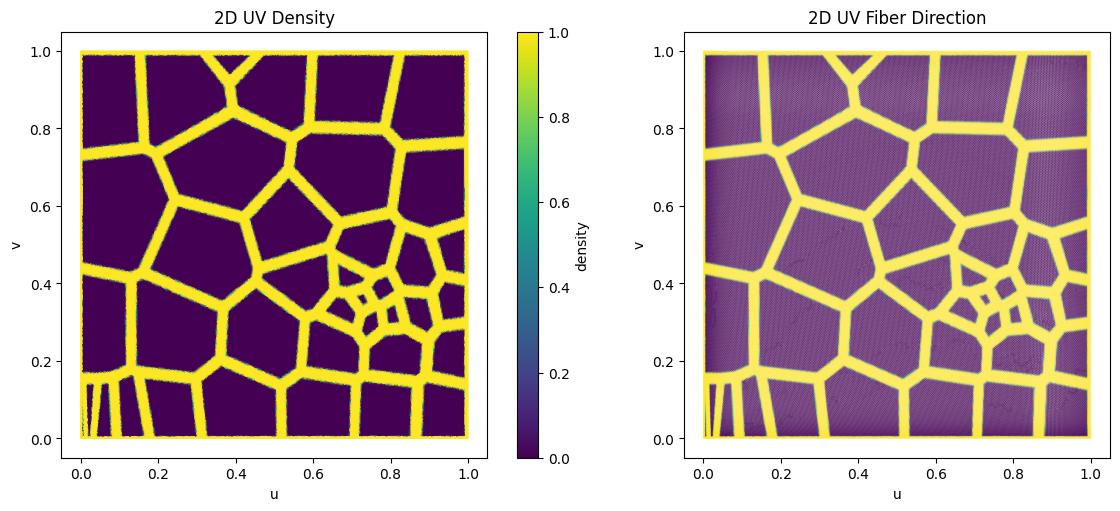

In [20]:

from Training.MainTrain import (
    _field_to_numpy,
    load_optimized_shell_function,
    evaluate_optimized_shell_function,
    visualize_optimized_shell_fields,
)

try:
    path = result["optimized_function_path"]
except :
    path = "/home/arash/HVD_SeedsBase/Case_Studies/FreeForm3CorrectedFEM_90_3d_Free/optimized_shell_function.pt"

opt_fn = load_optimized_shell_function(path, device="cuda")
fields = evaluate_optimized_shell_function(opt_fn)

vis = visualize_optimized_shell_fields(
    fields,
    show_2d=True,
    show_3d=True,
    fiber_stride=30,
    fiber_min_density=0.2,
    show_fiber_background=True,
)
rho = _field_to_numpy(fields["3d_density"]).reshape(-1).astype(np.float64)
vis["plotter"].show()

In [21]:
cfg = TrainingConfig(
    LoadingCase="all",

    # Geometry and seed initialization
    seed_number=40,
    use_balanced_seed_init=True,
    seed_init_fps_seed=11,
    strut_thickness=0.4,
    Edge_in_losses="all",

    # Seed separation
    min_seed_spacing=0.5,
    seed_spacing_power=2.0,
    lam_seed_spacing=1000.0,

    seed_spacing_safety_factor=1.05,
    seed_spacing_aggregate_temperature=0.005,

    seed_repulsion_factor=1.10,
    seed_repulsion_temperature_ratio=0.05,
    seed_repulsion_weight=1.0,



    # Decoder
    decoder_use_trim_activity=True,

    # Staged optimization
    eps=1e-12,
    scheduler_gamma=0.5,
    grad_clip_norm=2,
    log_every=300,

    # Decoder output
    use_3d_density_filter=False,
    generate_decoder_density_fiber=True,

    # Shared loss settings
    lam_cell_angle_uniform=0.5,
    lam_cell_radial_uniform=0.5,
    normalize_losses=True,

    # CVT
    cvt_temperature=0.01,
    curve_length_tolerance=0.10,
    curve_length_outlier_weight=5.0,

    # FEM
    fem_max_displacement=1.2,
    fem_yield_strength=400,
    fem_constraint_weight=100000,
    fem_stress_density_threshold=0.5,
    fem_training_safety_factor=0.7,
    fem_penal=3.0,
    fem_rho_min_ratio=1e-4,
    fem_rho_min_start=1e-3,
    fem_rho_min_end=1e-4,
    fem_density_floor=0.0,
    fem_baseline_weight=0.2,
    fem_violation_power=3.0,
    adaptive_fem_penalty=False,
    fem_lambda_initial=2.0,
    fem_lambda_min=2.0,
    fem_lambda_max=1e3,
    fem_lambda_growth=1.02,
    fem_lambda_decay=0.99,
    fem_constraint_tolerance=0.0,
    fem_safety_margin_weight = 0.05,
    fem_constraint_p_norm = 12.0,

    # Invalid FEM handling
    skip_bad_fem_steps=True,
    invalid_fem_patience=3,
    invalid_lr_factor=0.5,
    minimum_learning_rate=1e-7,
    invalid_fem_consumes_budget=True,
    debug_fem_integrity=True,
    save_fem_debug_history=True,

    # Stage 1
    stage1_min_steps=1,
    stage1_max_steps=200,
    stage1_patience=500,
    stage1_allow_seed_outside_domain=False,
    stage1_lam_fem=0.0,
    stage1_lam_cvt=5.0,
    stage1_lam_total_fiber_length=1.0,
    stage1_lam_l_curve_cell=0.5,
    stage1_scheduler_milestones=(0.5, 0.8),
    stage1_freeze_seeds=False,
    stage1_min_delta_abs=1e-4,
    stage1_min_delta_rel=1e-3,

    # Stage 2
    stage2_min_steps=1,
    stage2_max_steps=10000,
    stage2_patience=20000,
    stage2_allow_seed_outside_domain=False,  
    stage2_lam_fem=2,
    stage2_lam_cvt=1,
    stage2_lam_l_curve_cell=0,
    stage2_lam_total_fiber_length=5.0,
    stage2_scheduler_milestones=(0.8, 0.90),
    stage2_freeze_seeds=False,
    stage2_min_delta_abs=1e-4,
    stage2_min_delta_rel=1e-3,

    # Adaptive stage controller
    stage_topology_grace_steps=20,
    stage_topology_grace_max_resets=5,
    restore_transition_checkpoint=True,
    reset_optimizer_between_stages=True,
    stage_transition_selection="next_stage_objective",
    debug_stage_controller=False,

    # Learning rates
    lr_seed_refine=1e-4,
    lr_independent_seed_offsets=1e-4,
    lr_delta_head=1e-4,
    lr_mlp=1e-4,
    lr_decoder=1e-4,

    # Seed movement
    use_independent_seed_offsets=True,
    seed_offset_scale_start=0.1,
    seed_offset_scale_final=0.1,
    seed_offset_scale_ramp_frac=0.80,
    allow_seed_outside_domain=True,
    allow_seed_outside_domain_warmup_frac=0.01,
    use_rolling_seed_anchors=True,
    seed_anchor_warmup_frac=0.0,
    seed_anchor_momentum=0.05,
    anchor_guard_updates=True  ,
    disable_rolling_seed_anchors_for_curve_only=False,

    # Logging
    tensorboard_enabled=False,
    tensorboard_log_root="runs",

    MakeTimelaps=True,

)
trainer = NN_Trainer(
    generator=Face_Cad,
    viz=viz,
    decoder_cls=ContinuousVoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    face_mesh=face_mesh,
)


In [27]:
import torch
import torch.nn.functional as F
import pandas as pd

from Training.Loss_FEM import Loss_FEM


# ------------------------------------------------------------
# 1. Extract optimized fields and surface basis
# ------------------------------------------------------------
rho = fields["rho"].detach()

fiber_original = fields["fiber3d"].detach()

face_tensor = fields["face_tensor"]

Xu = face_tensor["Xu"].to(
    device=fiber_original.device,
    dtype=fiber_original.dtype,
)

Xv = face_tensor["Xv"].to(
    device=fiber_original.device,
    dtype=fiber_original.dtype,
)

eps = 1e-18


# ------------------------------------------------------------
# 2. Calculate unit surface normals
# ------------------------------------------------------------
surface_normal = F.normalize(
    torch.cross(Xu, Xv, dim=-1),
    dim=-1,
    eps=eps,
)


# Ensure the original fibre is exactly tangent to the surface.
fiber_tangent = (
    fiber_original
    - (
        fiber_original * surface_normal
    ).sum(dim=-1, keepdim=True)
    * surface_normal
)

fiber_tangent_norm = torch.linalg.norm(
    fiber_tangent,
    dim=-1,
    keepdim=True,
)

# Xu is used only as a fallback for degenerate vectors.
fallback_tangent = F.normalize(
    Xu,
    dim=-1,
    eps=eps,
)

fiber_tangent = torch.where(
    fiber_tangent_norm > eps,
    fiber_tangent / fiber_tangent_norm.clamp_min(eps),
    fallback_tangent,
)


# ------------------------------------------------------------
# 3. Rotate fibre direction by 90 degrees in tangent plane
# ------------------------------------------------------------
fiber_rotated_90 = F.normalize(
    torch.cross(
        surface_normal,
        fiber_tangent,
        dim=-1,
    ),
    dim=-1,
    eps=eps,
)


# Check the rotation
material_mask = rho >= float(cfg.fem_stress_density_threshold)

mean_orthogonality_error = (
    (
        fiber_tangent[material_mask]
        * fiber_rotated_90[material_mask]
    )
    .sum(dim=-1)
    .abs()
    .mean()
)

mean_tangent_error = (
    (
        fiber_rotated_90[material_mask]
        * surface_normal[material_mask]
    )
    .sum(dim=-1)
    .abs()
    .mean()
)

print(
    "Mean |original · rotated|:",
    float(mean_orthogonality_error.cpu()),
)

print(
    "Mean |rotated · normal|:",
    float(mean_tangent_error.cpu()),
)

Mean |original · rotated|: 7.12415149095591e-09
Mean |rotated · normal|: 4.408617471085563e-09


In [ ]:
fem_loss_evaluator = Loss_FEM(trainer)


def tensor_value(value):
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu().item())

    if value is None:
        return float("nan")

    return float(value)


def evaluate_fiber_case(
    case_name: str,
    fiber_surface: torch.Tensor,
) -> dict:
    fem_out = fem_loss_evaluator.evaluate(
        rho_surface=rho,
        fiber_surface=fiber_surface,

        max_displacement=float(
            cfg.fem_max_displacement
        ),
        yield_strength=float(
            cfg.fem_yield_strength
        ),

        constraint_weight=float(
            cfg.fem_constraint_weight
        ),
        baseline_weight=float(
            cfg.fem_baseline_weight
        ),
        violation_power=float(
            cfg.fem_violation_power
        ),

        stress_density_threshold=float(
            cfg.fem_stress_density_threshold
        ),

        rho_min_ratio=float(
            cfg.fem_rho_min_ratio
        ),
        penal=float(
            cfg.fem_penal
        ),
        eps=float(
            cfg.eps
        ),

        save_debug_history=False,
    )

    return {
        "case": case_name,
        "fem_valid": bool(
            fem_out["fem_valid"]
        ),
        "physical_feasible": bool(
            fem_out["physical_feasible"]
        ),
        "safety_margin_ok": bool(
            fem_out["safety_margin_satisfied"]
        ),
        "max_displacement": tensor_value(
            fem_out["displacement_max"]
        ),
        "displacement_ratio": tensor_value(
            fem_out["physical_displacement_ratio"]
        ),
        "max_stress": tensor_value(
            fem_out["stress_max"]
        ),
        "stress_ratio": tensor_value(
            fem_out["physical_stress_ratio"]
        ),
        "displacement_p_norm": tensor_value(
            fem_out.get("displacement_p_norm")
        ),
        "stress_p_norm": tensor_value(
            fem_out.get("stress_p_norm")
        ),
        "fem_total": tensor_value(
            fem_out["fem_total"]
        ),
    }

In [ ]:
comparison = [
    evaluate_fiber_case("Original", fiber_tangent),
    evaluate_fiber_case("Rotated 90 degrees", fiber_rotated_90),
]

comparison_df = pd.DataFrame(comparison).set_index("case")

original_u = comparison_df.loc["Original", "max_displacement"]
original_s = comparison_df.loc["Original", "max_stress"]

comparison_df["displacement_change_%"] = (
    100 * (comparison_df["max_displacement"] / original_u - 1)
)

comparison_df["stress_change_%"] = (
    100 * (comparison_df["max_stress"] / original_s - 1)
)

display(comparison_df)

In [ ]:

def to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)
edge_colors = {
    0: "black",
    1: "orange",
    2: "gray",
    3: "orange",
    4: "cyan",
}
points_xyz = to_np(face_mesh["points_xyz"])
faces = to_np(face_mesh["faces_ijk"]).astype(int)
curves_xyz = to_np(result["best_edge_curves_xyz"])
edge_type = to_np(result["best_edge_type"])
seeds_xyz = to_np(result["best_seed_points_xyz"])

pv_faces = np.hstack([
    np.full((faces.shape[0], 1), 3, dtype=np.int64),
    faces.astype(np.int64),
]).ravel()

plotter = pv.Plotter()
surf = pv.PolyData(points_xyz, pv_faces)
plotter.add_mesh(surf, color="white", opacity=0.25, show_edges=False)

tube_radius = 0.075  # adjust if too thin/thick

for edge_id, c in enumerate(curves_xyz):
    if c.shape[0] < 2:
        continue
    line = pv.PolyData(c.astype(np.float32))
    line.lines = np.hstack([[c.shape[0]], np.arange(c.shape[0])]).astype(np.int64)
    tube = line.tube(radius=tube_radius, n_sides=12)
    plotter.add_mesh(tube, color=edge_colors.get(int(edge_type[edge_id]), "gray"), smooth_shading=True)

if seeds_xyz is not None:
    plotter.add_mesh(
        pv.PolyData(seeds_xyz.astype(np.float32)),
        color="red",
        point_size=10,
        render_points_as_spheres=True,
    )
plotter.add_axes()
plotter.show()

In [ ]:
from Utils.HVDStepExporter import HVDStepExporter

exporter = HVDStepExporter(
    fuse=False,              # faster; Abaqus imports as compound/multiple solids
    add_joint_spheres=True,  # fills tube joints
)

summary = exporter.export_optimization_output(
    result,                  # output dict from trainer optimization
    "optimized_HVD_shell.step",
)

print(summary)